In [2040]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
import os
import sys 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from pandas_plink import read_plink1_bin
import glob
from sklearn.preprocessing import StandardScaler


In [2041]:
DATA = "balanced"

In [2042]:
G = read_plink1_bin(f"data/qc/{DATA}.QC.bed", f"data/qc/{DATA}.QC.bim", f"data/qc/{DATA}.QC.fam", verbose=False)

In [2043]:
labels = pd.read_csv(f"data/raw/{DATA}/{DATA}.pheno", sep='\t')  # columns: iid, phenotype

In [2044]:
labels.head()

,FID,IID,phenotype
0,GENERATEDSAMPLE0,GENERATEDSAMPLE0,1
1,GENERATEDSAMPLE1,GENERATEDSAMPLE1,0
2,GENERATEDSAMPLE2,GENERATEDSAMPLE2,0
3,GENERATEDSAMPLE3,GENERATEDSAMPLE3,0
4,GENERATEDSAMPLE4,GENERATEDSAMPLE4,0


In [2045]:
labels.shape

(10000, 3)

In [2046]:
# DATA = "UKB_CRC_SYN_own_sumstat"

In [2047]:
prcise_df = pd.read_csv(f"data/results/{DATA}/prsice/prsice.best", sep=" ")

In [2048]:
prcise_df.head()

,FID,IID,In_Regression,PRS
0,GENERATEDSAMPLE0,GENERATEDSAMPLE0,Yes,0.000025
1,GENERATEDSAMPLE1,GENERATEDSAMPLE1,Yes,-0.000489
2,GENERATEDSAMPLE2,GENERATEDSAMPLE2,Yes,-0.001077
3,GENERATEDSAMPLE3,GENERATEDSAMPLE3,Yes,-0.000059
4,GENERATEDSAMPLE4,GENERATEDSAMPLE4,Yes,-0.000256


In [2049]:
lassosum_df = pd.read_csv(f"data/results/{DATA}/lassosum/_PRS.csv", sep=",")

In [2050]:
lassosum_df.head()

,FID,IID,PRS
0,GENERATEDSAMPLE0,GENERATEDSAMPLE0,4.916076
1,GENERATEDSAMPLE1,GENERATEDSAMPLE1,-3.342332
2,GENERATEDSAMPLE2,GENERATEDSAMPLE2,-8.986290
3,GENERATEDSAMPLE3,GENERATEDSAMPLE3,3.525192
4,GENERATEDSAMPLE4,GENERATEDSAMPLE4,1.266865


In [2051]:
lassosum2_df = pd.read_csv(f"data/results/{DATA}/lassosum2/lassosum2_PRS.csv", sep=",")

In [2052]:
lassosum2_df.head()

,FID,IID,PRS
0,GENERATEDSAMPLE0,GENERATEDSAMPLE0,-0.058564
1,GENERATEDSAMPLE1,GENERATEDSAMPLE1,-0.296165
2,GENERATEDSAMPLE2,GENERATEDSAMPLE2,-0.067653
3,GENERATEDSAMPLE3,GENERATEDSAMPLE3,-0.276711
4,GENERATEDSAMPLE4,GENERATEDSAMPLE4,-0.107299


In [2053]:
LDpred2_df = pd.read_csv(f"data/results/{DATA}/ldpred2/ldpred2_PRS.csv", sep=",")

In [2054]:
LDpred2_df.head()

,FID,IID,PRS
0,GENERATEDSAMPLE0,GENERATEDSAMPLE0,-0.000992
1,GENERATEDSAMPLE1,GENERATEDSAMPLE1,-0.001806
2,GENERATEDSAMPLE2,GENERATEDSAMPLE2,-0.003354
3,GENERATEDSAMPLE3,GENERATEDSAMPLE3,-0.000182
4,GENERATEDSAMPLE4,GENERATEDSAMPLE4,-0.000338


In [2055]:
sct_df = pd.read_csv(f"data/results/{DATA}/sct/sct_PRS.csv", sep=",")

In [2056]:
sct_df.head()

,FID,IID,PRS,is_train
0,GENERATEDSAMPLE0,GENERATEDSAMPLE0,1.510905,False
1,GENERATEDSAMPLE1,GENERATEDSAMPLE1,-0.907624,True
2,GENERATEDSAMPLE2,GENERATEDSAMPLE2,-2.023339,True
3,GENERATEDSAMPLE3,GENERATEDSAMPLE3,0.795730,True
4,GENERATEDSAMPLE4,GENERATEDSAMPLE4,0.580258,True


In [2057]:
sbayes_betas = pd.read_csv(f"data/results/{DATA}/sbayesr/sbayesr_model_sbrc.txt", sep="\t")

In [2058]:
#rename columns
sbayes_betas.columns = ["snp", "a0", "beta", "se", "pip", "betalast"]

In [2059]:
# sbayes_betas.head()

In [2060]:
# PRS-CS

files = glob.glob(f'data/results/{DATA}/prs_cs/*.txt')
prs_cs_betas = pd.concat([pd.read_csv(f, sep="\t", header=None) for f in files], ignore_index=True)

prs_cs_betas.columns = ["chr", "snp", "pos", "a0", "a1", "beta"]


In [2061]:
prs_cs_betas.head()

,chr,snp,pos,a0,a1,beta
0,8,rs888577,239324,T,C,-0.000441
1,8,rs888576,239544,T,C,-0.000803
2,8,rs17665364,365789,T,C,-0.000574
3,8,rs6994245,565639,C,T,-0.000348
4,8,rs11777864,828266,G,A,0.000166


In [2062]:
# PRS-CSx   

files = glob.glob(f'data/results/{DATA}/prs_csx/*.txt')
prs_csx_betas = pd.concat([pd.read_csv(f, sep="\t", header=None) for f in files], ignore_index=True)

prs_csx_betas.columns = ["chr", "snp", "pos", "a0", "a1", "beta"]

In [2063]:
prs_csx_betas.head()

,chr,snp,pos,a0,a1,beta
0,4,rs11730564,514201,T,G,0.000219
1,4,rs12646225,696848,T,C,0.000066
2,4,rs4690326,953698,A,C,0.000072
3,4,rs3796622,983060,T,C,-0.000105
4,4,rs615381,1087531,C,T,-0.000358


In [2064]:
# calculate PRS for missing models

bim = G.coords
bim_df = pd.DataFrame({
    'snp': G.variant.snp.values,
    'a0':  G.variant.a0.values,   # reference allele
    'a1':  G.variant.a1.values,   # alternative allele
    'i':   np.arange(G.shape[1])  # column index
})

In [2065]:
merged_sbayes = sbayes_betas.merge(bim_df, on='snp', suffixes=('_sbayes', '_bim'))
aligned_sbayes = merged_sbayes[merged_sbayes['a0_sbayes'] == merged_sbayes['a0_bim']].copy()

# Extract genotype matrix for matched SNPs
indices = aligned_sbayes['i'].values
betas   = aligned_sbayes['beta'].values

# Load into memory as numpy (can be large — chunk if needed)
G_sub = G[:, indices].values  # shape: (n_samples, n_snps)

prs_sbayes = G_sub @ betas  # shape: (n_samples,)

# Package results
sbayes_df = pd.DataFrame({
    'IID': G.sample.iid.values,
    'FID': G.sample.fid.values,
    'PRS': prs_sbayes
})

In [2066]:
sbayes_df.head()

,IID,FID,PRS
0,GENERATEDSAMPLE0,GENERATEDSAMPLE0,13808.821584
1,GENERATEDSAMPLE1,GENERATEDSAMPLE1,13797.209409
2,GENERATEDSAMPLE2,GENERATEDSAMPLE2,13887.634716
3,GENERATEDSAMPLE3,GENERATEDSAMPLE3,14076.016017
4,GENERATEDSAMPLE4,GENERATEDSAMPLE4,13863.568614


In [2067]:
# sbayes_betas = pd.read_csv(f"data/results/{DATA}/sbayesr/prs_sbrc.profile", sep='\s+')

# sbayes_df = sbayes_betas[['IID', 'FID', 'SCORE']].copy()
# sbayes_df.columns = ['IID', 'FID', 'PRS']

In [2068]:
# sbayes_df.head()

In [2069]:
merged_cs = prs_cs_betas.merge(bim_df, on='snp', suffixes=('_cs', '_bim'))
aligned_cs = merged_cs[merged_cs['a0_cs'] == merged_cs['a0_bim']].copy()

# Extract genotype matrix for matched SNPs
indices = aligned_cs['i'].values
betas   = aligned_cs['beta'].values

# Load into memory as numpy (can be large — chunk if needed)
G_sub = G[:, indices].values  # shape: (n_samples, n_snps)

prs_cs = G_sub @ betas  # shape: (n_samples,)

# Package results
cs_df = pd.DataFrame({
    'IID': G.sample.iid.values,
    'FID': G.sample.fid.values,
    'PRS': prs_cs
})

In [2070]:
cs_df.head()

,IID,FID,PRS
0,GENERATEDSAMPLE0,GENERATEDSAMPLE0,-0.522808
1,GENERATEDSAMPLE1,GENERATEDSAMPLE1,-0.279994
2,GENERATEDSAMPLE2,GENERATEDSAMPLE2,-0.355540
3,GENERATEDSAMPLE3,GENERATEDSAMPLE3,-0.466576
4,GENERATEDSAMPLE4,GENERATEDSAMPLE4,-0.465895


In [2071]:
merged_cs_x = prs_csx_betas.merge(bim_df, on='snp', suffixes=('_cs', '_bim'))
aligned_cs_x = merged_cs_x[merged_cs_x['a0_cs'] == merged_cs_x['a0_bim']].copy()

# Extract genotype matrix for matched SNPs
indices = aligned_cs_x['i'].values
betas   = aligned_cs_x['beta'].values

# Load into memory as numpy (can be large — chunk if needed)
G_sub = G[:, indices].values  # shape: (n_samples, n_snps)

prs_cs_x = G_sub @ betas  # shape: (n_samples,)

# Package results
cs_x_df = pd.DataFrame({
    'IID': G.sample.iid.values,
    'FID': G.sample.fid.values,
    'PRS': prs_cs_x
})

In [2072]:
cs_x_df.head()

,IID,FID,PRS
0,GENERATEDSAMPLE0,GENERATEDSAMPLE0,-0.623746
1,GENERATEDSAMPLE1,GENERATEDSAMPLE1,-0.438180
2,GENERATEDSAMPLE2,GENERATEDSAMPLE2,-0.458570
3,GENERATEDSAMPLE3,GENERATEDSAMPLE3,-0.573972
4,GENERATEDSAMPLE4,GENERATEDSAMPLE4,-0.606500


In [2073]:
folds = []

for fold in os.listdir(f"data/qc/{DATA}/folds/"):
    fold_path = os.path.join(f"data/qc/{DATA}/folds/", fold)
    fold_iids = pd.read_csv(fold_path, sep=" ")
    fold_iids = fold_iids['IID'].tolist()  # convert to list of iids
    print(len(fold_iids))
    folds.append(fold_iids)



1000
1000
1000
1000
1000
1000
1000
1000
1000
1000


In [2074]:
prs_dfs = [ prcise_df, lassosum_df, lassosum2_df, LDpred2_df, sct_df, sbayes_df, cs_df, cs_x_df]

In [2075]:
prs_names = ["PRSice", "Lassosum", "Lassosum2", "LDpred2", "SCT", "SBayesR", "PRS-CS", "PRS-CSx"]

In [2076]:
# prs_dfs = [ prcise_df, lassosum_df, lassosum2_df, LDpred2_df, sct_df, cs_df, cs_x_df]

In [2077]:
# prs_names = ["PRSice", "Lassosum", "Lassosum2", "LDpred2", "SCT", "PRS-CS", "PRS-CSx"]

In [2078]:
# make all IID columns int and all PRS columns float
for df in prs_dfs:
    df['IID'] = df['IID'].astype(str)
    df['PRS'] = df['PRS'].astype(float)    

In [2079]:
prs_merged = labels[['IID', 'phenotype']].copy()

for i, df in enumerate(prs_dfs):
    df = df.rename(columns={'PRS': f'PRS_{prs_names[i]}'})
    prs_merged = prs_merged.merge(df[['IID', f'PRS_{prs_names[i]}']], on='IID', how='inner')

prs_features = [f'PRS_{name}' for name in prs_names]
print(prs_merged.shape)

(10000, 10)


In [2080]:

def nagelkerke_r2(model, X, y):
    n = len(y)
    
    # Log-likelihood of fitted model
    y_pred_prob = model.predict_proba(X)[:, 1]   
    print(y_pred_prob) 
    ll_model = np.sum(y * np.log(y_pred_prob) + (1 - y) * np.log(1 - y_pred_prob))
    
    # Log-likelihood of null model (intercept only)
    p_null = np.mean(y)
    ll_null = n * (p_null * np.log(p_null) + (1 - p_null) * np.log(1 - p_null))
    
    # Cox & Snell R²
    cox_snell = 1 - np.exp((2 / n) * (ll_null - ll_model))
    
    # Nagelkerke R² (scaled so max = 1)
    max_r2 = 1 - np.exp((2 / n) * ll_null)
    nagelkerke = cox_snell / max_r2
    
    return nagelkerke

In [2081]:
from sklearn.metrics import balanced_accuracy_score, accuracy_score, average_precision_score


In [2082]:
# --- K-Fold CV: train separate LR per PRS model, evaluate AUC ---

results = {f'PRS_{prs_names}': [] for prs_names in prs_names}  # AUC per fold per model
results['ensemble'] = []  # optional: LR trained on all 8 features

accuracy_results = {f'PRS_{prs_names}': [] for prs_names in prs_names}
accuracy_results['ensemble'] = []

results_pr_auc = {f'PRS_{prs_names}': [] for prs_names in prs_names}
results_pr_auc['ensemble'] = []

for fold_idx, test_ids in enumerate(folds):
    test_mask  = prs_merged['IID'].isin(test_ids)
    train_mask = ~test_mask

    train_df = prs_merged[train_mask]
    test_df  = prs_merged[test_mask]

    y_train = train_df['phenotype'].values
    y_test  = test_df['phenotype'].values

    # --- Per-model LR ---
    for feature in prs_features:
        
        X_train = train_df[[feature]].values
        X_test  = test_df[[feature]].values

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_train, y_train)
        
        auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
        results[feature].append(auc)
        
        pr_auc = average_precision_score(y_test, lr.predict_proba(X_test)[:, 1])
        results_pr_auc[feature].append(pr_auc)
        
        accuracy = balanced_accuracy_score(y_test, lr.predict(X_test))
        accuracy_results[feature].append(accuracy)
 

    # --- Ensemble LR (all 8 PRS as features) ---
    X_train_all = train_df[prs_features].values
    X_test_all  = test_df[prs_features].values

    scaler = StandardScaler()
    X_train_all = scaler.fit_transform(X_train_all)
    X_test_all  = scaler.transform(X_test_all)

    lr_ens = LogisticRegression(max_iter=1000)
    lr_ens.fit(X_train_all, y_train)

    auc_ens = roc_auc_score(y_test, lr_ens.predict_proba(X_test_all)[:, 1])
    pr_auc_ens = average_precision_score(y_test, lr_ens.predict_proba(X_test_all)[:, 1])
    accuracy_ens = balanced_accuracy_score(y_test, lr_ens.predict(X_test_all))
    
    results['ensemble'].append(auc_ens)
    accuracy_results['ensemble'].append(accuracy_ens)
    results_pr_auc['ensemble'].append(pr_auc_ens)

    print(f"Fold {fold_idx+1} done")

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done
Fold 6 done
Fold 7 done
Fold 8 done
Fold 9 done
Fold 10 done


In [2083]:
# --- Summarise results ---
summary = pd.DataFrame(results)
summary.index = [f'Fold_{i+1}' for i in range(len(folds))]
summary.loc['Mean'] = summary.mean()
summary.loc['Std']  = summary.std()

print(summary.round(4))

         PRS_PRSice  PRS_Lassosum  PRS_Lassosum2  PRS_LDpred2  PRS_SCT  \
Fold_1       0.7568        0.7571         0.6292       0.7301   0.7750   
Fold_2       0.6956        0.6958         0.6127       0.6617   0.7245   
Fold_3       0.7141        0.7091         0.6096       0.6808   0.7264   
Fold_4       0.7526        0.7400         0.6265       0.7179   0.7779   
Fold_5       0.7434        0.7355         0.6484       0.7117   0.7630   
Fold_6       0.7600        0.7572         0.6298       0.7273   0.7731   
Fold_7       0.7245        0.7191         0.6451       0.6942   0.7611   
Fold_8       0.7314        0.7188         0.6209       0.6887   0.7541   
Fold_9       0.7285        0.7192         0.6274       0.6902   0.7443   
Fold_10      0.7288        0.7204         0.6171       0.6991   0.7501   
Mean         0.7336        0.7272         0.6267       0.7002   0.7550   
Std          0.0191        0.0189         0.0120       0.0205   0.0180   

         PRS_SBayesR  PRS_PRS-CS  PRS

In [2084]:
summary_accuracy = pd.DataFrame(accuracy_results)
summary_accuracy.index = [f'Fold_{i+1}' for i in range(len(folds))]
summary_accuracy.loc['Mean'] = summary_accuracy.mean()
summary_accuracy.loc['Std']  = summary_accuracy.std()

print(summary_accuracy.round(4))

         PRS_PRSice  PRS_Lassosum  PRS_Lassosum2  PRS_LDpred2  PRS_SCT  \
Fold_1       0.6897        0.6968         0.5815       0.6605   0.7037   
Fold_2       0.6261        0.6322         0.5714       0.6050   0.6545   
Fold_3       0.6647        0.6588         0.5802       0.6338   0.6698   
Fold_4       0.6844        0.6725         0.5925       0.6625   0.7015   
Fold_5       0.6773        0.6742         0.6028       0.6582   0.7073   
Fold_6       0.6895        0.6907         0.5957       0.6665   0.7117   
Fold_7       0.6635        0.6594         0.5940       0.6503   0.6985   
Fold_8       0.6448        0.6589         0.5904       0.6397   0.6840   
Fold_9       0.6717        0.6557         0.5933       0.6265   0.6756   
Fold_10      0.6563        0.6495         0.5760       0.6323   0.6724   
Mean         0.6668        0.6649         0.5878       0.6435   0.6879   
Std          0.0194        0.0182         0.0094       0.0186   0.0183   

         PRS_SBayesR  PRS_PRS-CS  PRS

In [2085]:
summary_pr_auc = pd.DataFrame(results_pr_auc)
summary_pr_auc.index = [f'Fold_{i+1}' for i in range(len(folds))]
summary_pr_auc.loc['Mean'] = summary_pr_auc.mean()
summary_pr_auc.loc['Std']  = summary_pr_auc.std()
print(summary_pr_auc.round(4))

         PRS_PRSice  PRS_Lassosum  PRS_Lassosum2  PRS_LDpred2  PRS_SCT  \
Fold_1       0.7551        0.7525         0.6188       0.7262   0.7689   
Fold_2       0.7038        0.7051         0.6184       0.6754   0.7238   
Fold_3       0.7047        0.6988         0.5977       0.6660   0.7188   
Fold_4       0.7582        0.7421         0.6212       0.7158   0.7898   
Fold_5       0.7283        0.7137         0.6418       0.6976   0.7454   
Fold_6       0.7538        0.7509         0.6223       0.7264   0.7683   
Fold_7       0.7210        0.7113         0.6357       0.6923   0.7568   
Fold_8       0.7319        0.7241         0.6237       0.6808   0.7597   
Fold_9       0.7143        0.7073         0.6174       0.6715   0.7365   
Fold_10      0.7300        0.7213         0.6254       0.6954   0.7521   
Mean         0.7301        0.7227         0.6222       0.6948   0.7520   
Std          0.0191        0.0184         0.0111       0.0209   0.0206   

         PRS_SBayesR  PRS_PRS-CS  PRS

In [2086]:
# write all results to file, with a row indicating which metric it is (AUC, accuracy, PR-AUC) and which model (PRSice, Lassosum, etc.) for each fold, and the mean and std across folds and one column indicatin the dataset name
summary_long = summary.reset_index().melt(id_vars='index', var_name='PRS Method', value_name='AUC')
summary_accuracy_long = summary_accuracy.reset_index().melt(id_vars='index', var_name='PRS Method', value_name='Balanced Accuracy')
summary_pr_auc_long = summary_pr_auc.reset_index().melt(id_vars='index', var_name='PRS Method', value_name='PR AUC')

summary_all = pd.merge(summary_long, summary_accuracy_long, on=['index', 'PRS Method'])
summary_all = pd.merge(summary_all, summary_pr_auc_long, on=['index', 'PRS Method'])


summary_all['Dataset'] = 'Balanced Genomator'

summary_all.rename(columns={'index': 'CV'}, inplace=True)

In [2087]:
summary_all.head(20)

,CV,PRS Method,AUC,Balanced Accuracy,PR AUC,Dataset
0,Fold_1,PRS_PRSice,0.756760,0.689715,0.755058,Balanced Genomator
1,Fold_2,PRS_PRSice,0.695640,0.626123,0.703763,Balanced Genomator
2,Fold_3,PRS_PRSice,0.714108,0.664696,0.704735,Balanced Genomator
3,Fold_4,PRS_PRSice,0.752604,0.684420,0.758156,Balanced Genomator
4,Fold_5,PRS_PRSice,0.743386,0.677287,0.728304,Balanced Genomator
5,Fold_6,PRS_PRSice,0.759979,0.689537,0.753845,Balanced Genomator
6,Fold_7,PRS_PRSice,0.724498,0.663486,0.720995,Balanced Genomator
7,Fold_8,PRS_PRSice,0.731367,0.644804,0.731863,Balanced Genomator
8,Fold_9,PRS_PRSice,0.728499,0.671684,0.714317,Balanced Genomator
9,Fold_10,PRS_PRSice,0.728767,0.656303,0.730039,Balanced Genomator


In [2088]:
summary_all.to_csv(f"plots/{DATA}_summary_results_updated.csv", index=False)

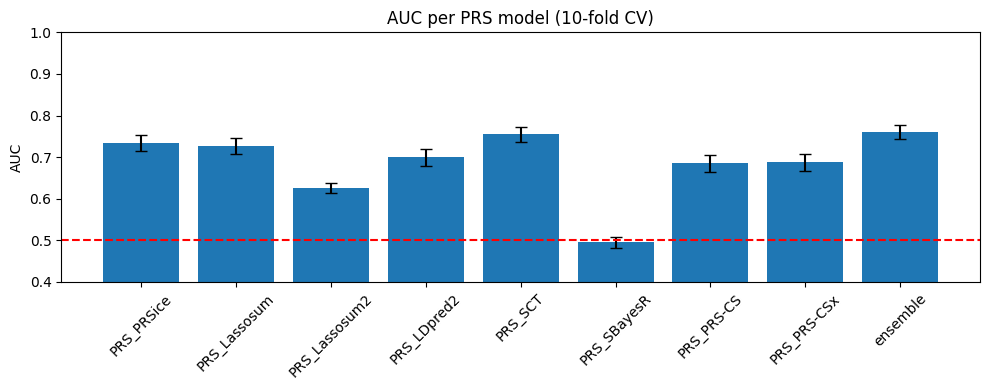

In [2089]:
# --- Optional: visualise ---
import matplotlib.pyplot as plt

means = summary.loc['Mean']
stds  = summary.loc['Std']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(means.index, means.values, yerr=stds.values, capsize=4)
ax.axhline(0.5, color='red', linestyle='--', label='Random')
ax.set_ylabel('AUC')
ax.set_title('AUC per PRS model (10-fold CV)')
ax.set_ylim(0.4, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'plots/prs_lr_auc_{DATA}_updated.png', dpi=150)
plt.show()

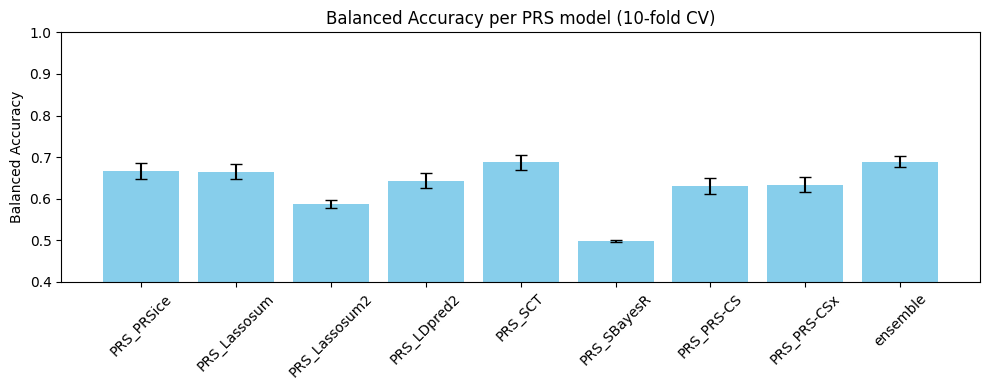

In [2090]:
means_accuracy = summary_accuracy.loc['Mean']
stds_accuracy  = summary_accuracy.loc['Std']
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(means_accuracy.index, means_accuracy.values, yerr=stds_accuracy.values,
         capsize=4, color='skyblue')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Balanced Accuracy per PRS model (10-fold CV)')
ax.set_ylim(0.4, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'plots/prs_lr_balanced_accuracy_{DATA}_updated.png', dpi=150)
plt.show()

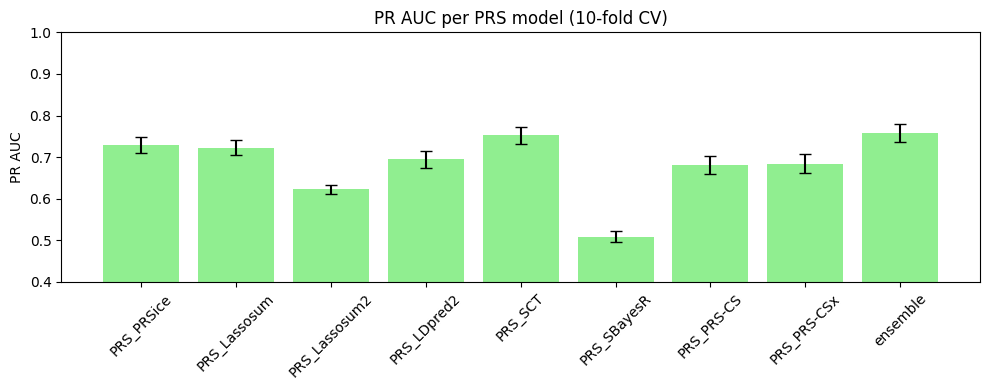

In [2091]:
means_pr_auc = summary_pr_auc.loc['Mean']
stds_pr_auc  = summary_pr_auc.loc['Std']
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(means_pr_auc.index, means_pr_auc.values, yerr=stds_pr_auc.values, capsize=4, color='lightgreen')
ax.set_ylabel('PR AUC')
ax.set_title('PR AUC per PRS model (10-fold CV)')
ax.set_ylim(0.4, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'plots/prs_lr_pr_auc_{DATA}_updated.png', dpi=150)
plt.show()